In [2]:
# CELL 1 — Imports
# Bringing in all the libraries we need for the entire project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [3]:
# CELL 2 — Load the dataset and explore it
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())


(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

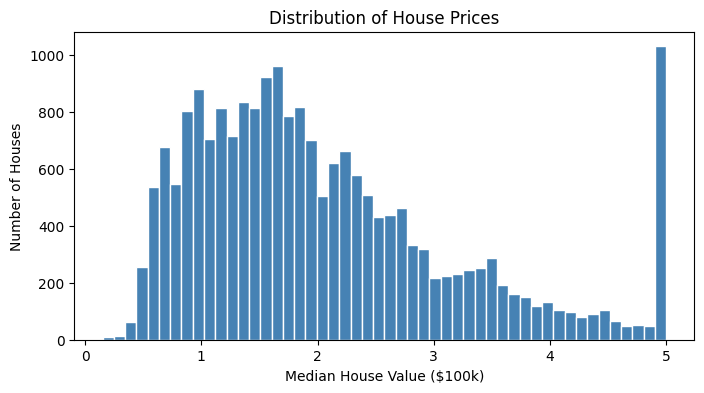

In [4]:
# CELL 3 — Visualise how house prices are distributed
plt.figure(figsize=(8, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Number of Houses')
plt.show()

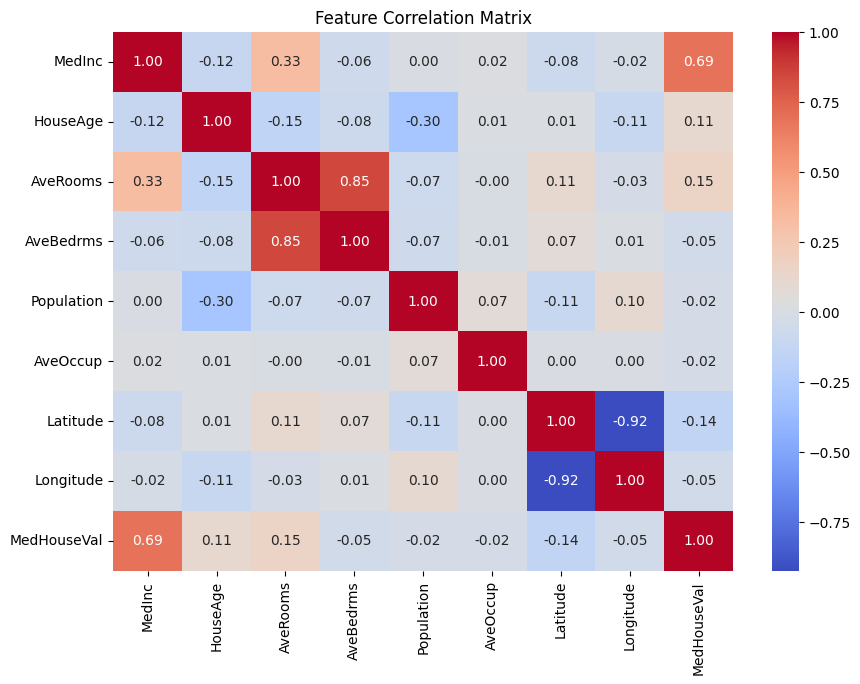

In [5]:
# CELL 4 — Correlation heatmap
# Shows how strongly each feature relates to every other feature
plt.figure(figsize=(10, 7))                                      # bigger canvas for the heatmap
sns.heatmap(df.corr(),      # df.corr() calculates correlation (-1 to +1) between all column pairs
            annot=True,     # annot=True prints the numbers inside each colored square
            fmt='.2f',      # fmt='.2f' rounds numbers to 2 decimal places
            cmap='coolwarm' # coolwarm = red for positive, blue for negative correlation
            )
plt.title('Feature Correlation Matrix')
plt.show()

# After seeing the heatmap, look for which features have
# the highest correlation with MedHouseVal (last row/column)
# Those are your most powerful predictors!

In [6]:
# CELL 5 — Check for missing values
# Always do this before anything else — missing values break most ML models
print(df.isnull().sum())  
# isnull() returns True/False for each cell
# .sum() counts the Trues per column
# 0 for every column = no missing values = we're lucky!

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [7]:
# CELL 6 — Separate features (X) from target (y)
X = df.drop('MedHouseVal', axis=1)  # X = everything EXCEPT price (these are inputs)
y = df['MedHouseVal']               # y = just the price column (this is what we predict)

print("Features shape:", X.shape)   # should show (20640, 8) — 8 input columns
print("Target shape:", y.shape)     # should show (20640,) — one price per house
print("\nFeature columns:", X.columns.tolist())  # lists all 8 feature names

Features shape: (20640, 8)
Target shape: (20640,)

Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [8]:
# CELL 7 — Split data into training and testing sets
from sklearn.model_selection import train_test_split  
# importing the function that splits our data into 2 parts

X_train, X_test, y_train, y_test = train_test_split(
    X,              # our 8-column features table
    y,              # our price list
    test_size=0.2,  # 20% of data goes to testing, 80% for training
    random_state=42 # fixed number so we get same split every time we run
)

# Let's see how many houses ended up in each set
print(f"Training samples: {X_train.shape[0]}")  # should be ~16,512 (80%)
print(f"Testing samples:  {X_test.shape[0]}")   # should be ~4,128  (20%)
print(f"Training features shape: {X_train.shape}")  # rows x columns
print(f"Testing features shape:  {X_test.shape}")   # rows x columns

Training samples: 16512
Testing samples:  4128
Training features shape: (16512, 8)
Testing features shape:  (4128, 8)


In [9]:
# CELL 8 — Scale all features to the same range
from sklearn.preprocessing import StandardScaler  
# StandardScaler transforms each column to have mean=0 and std=1

scaler = StandardScaler()  
# creates the scaler object — like a calculator that's not switched on yet

X_train_scaled = scaler.fit_transform(X_train)  
# fit   = scaler LEARNS the mean and std FROM training data
# transform = scaler APPLIES the scaling to training data
# both happen together in one step

X_test_scaled = scaler.transform(X_test)  
# ONLY transforms test data using what it already learned from training
# we NEVER fit on test data — that would be data leakage (cheating!)

# verify scaling worked — mean should be ~0.0, std should be ~1.0
print("Mean of first column before scaling:", X_train.iloc[:, 0].mean().round(4))
print("Mean of first column after  scaling:", X_train_scaled[:, 0].mean().round(4))
print("Std  of first column before scaling:", X_train.iloc[:, 0].std().round(4))
print("Std  of first column after  scaling:", X_train_scaled[:, 0].std().round(4))

Mean of first column before scaling: 3.8808
Mean of first column after  scaling: -0.0
Std  of first column before scaling: 1.9043
Std  of first column after  scaling: 1.0


In [10]:
# CELL 9 — Create new features from existing ones
df_eng = df.copy()  
# .copy() makes a full independent copy of df
# without this, changes to df_eng would also change df

# NEW FEATURE 1 — rooms per person
# a house with 8 rooms and 8 people is very different 
# from a house with 8 rooms and 2 people
df_eng['RoomsPerPerson'] = df_eng['AveRooms'] / df_eng['AveOccup']

# NEW FEATURE 2 — bedroom ratio
# what fraction of all rooms are bedrooms?
# high ratio = mostly bedrooms (small apartment)
# low ratio  = many living spaces (family home)
df_eng['BedroomRatio'] = df_eng['AveBedrms'] / df_eng['AveRooms']

# NEW FEATURE 3 — population density
# estimates how many households are in the neighborhood
df_eng['PopulationDensity'] = df_eng['Population'] / df_eng['AveOccup']

# confirm new features were added
print("Original columns:", df.shape[1])       # should be 9
print("New columns:", df_eng.shape[1])         # should be 12
print("\nAll columns now:", df_eng.columns.tolist())

Original columns: 9
New columns: 12

All columns now: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerPerson', 'BedroomRatio', 'PopulationDensity']


In [11]:
# CELL 10 — Re-split data using the new engineered feature set
X2 = df_eng.drop('MedHouseVal', axis=1)  
# new feature matrix — now has 11 columns instead of 8
# (original 8 + our 3 new engineered features)

y2 = df_eng['MedHouseVal']               
# target stays exactly the same — still predicting house price

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,          # using new feature set this time
    test_size=0.2,   # same 80/20 split
    random_state=42  # same seed = same rows in train/test as before
)                    # this is important for fair comparison later!

# re-fit scaler on new feature set (it has more columns now)
X2_train_scaled = scaler.fit_transform(X2_train)  
# learns new means and stds for all 11 columns

X2_test_scaled = scaler.transform(X2_test)        
# applies same scaling to test set

print("Original feature count:", X_train.shape[1])   # 8 columns
print("Engineered feature count:", X2_train.shape[1]) # 11 columns
print("\nNew feature names:", X2.columns.tolist())

Original feature count: 8
Engineered feature count: 11

New feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerPerson', 'BedroomRatio', 'PopulationDensity']


In [12]:
# CELL 11 — Import models and define evaluation function
from sklearn.linear_model import LinearRegression     
# simple straight-line model — our baseline

from sklearn.ensemble import RandomForestRegressor    
# powerful tree-based model — our main model

from sklearn.metrics import mean_squared_error, r2_score  
# two functions to measure how good our predictions are

# reusable function to evaluate any model
def evaluate(name, y_true, y_pred):
    # y_true = actual real prices from the dataset
    # y_pred = prices our model guessed
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # RMSE = average prediction error in $100k
    # lower is better — 0.5 means off by $50,000 on average
    
    r2 = r2_score(y_true, y_pred)
    # R² = how much of price variation the model explains
    # 1.0 = perfect, 0.0 = no better than guessing the average price
    
    print(f"{name:35s}  RMSE: {rmse:.4f}   R²: {r2:.4f}")

print("Models and evaluation function ready!")

Models and evaluation function ready!


In [13]:
# CELL 12 — Model 1: Linear Regression (your baseline)
# always start simple before trying complex models

lr = LinearRegression()  
# creates the model object — not trained yet, just created
# Linear Regression finds the best straight line through the data
# formula it learns: price = (w1 x MedInc) + (w2 x HouseAge) + ... + bias

lr.fit(X_train_scaled, y_train)  
# THIS is where actual learning happens
# model looks at 16,512 houses and their prices
# adjusts its internal weights until predictions are as close as possible
# .fit() = train = learn

lr_preds = lr.predict(X_test_scaled)  
# now model sees 4,128 houses it has NEVER seen before
# uses what it learned to guess the price of each one
# .predict() = use the learned weights to make guesses

# check BOTH train and test scores to detect overfitting
lr_train_preds = lr.predict(X_train_scaled)  # predict on TRAINING data
evaluate("Linear Regression TRAIN", y_train, lr_train_preds)
evaluate("Linear Regression TEST ", y_test,  lr_preds)

# if train score >> test score = overfitting problem
# if train and test scores are close = healthy model

Linear Regression TRAIN              RMSE: 0.7197   R²: 0.6126
Linear Regression TEST               RMSE: 0.7456   R²: 0.5758


In [14]:
# CELL 13 — Model 2: Random Forest (more powerful)
rf = RandomForestRegressor(
    n_estimators=100,  # build 100 decision trees
    random_state=42    # same seed for reproducibility
)
# Random Forest builds MANY trees, each seeing random subsets
# of data and features, then averages all their predictions
# averaging reduces errors that any single tree would make

rf.fit(X_train_scaled, y_train)  
# trains all 100 trees — takes 10-20 seconds, be patient!

rf_preds = rf.predict(X_test_scaled)  
# each tree votes, forest takes the average prediction

# compare train vs test again
rf_train_preds = rf.predict(X_train_scaled)
evaluate("Random Forest TRAIN", y_train, rf_train_preds)
evaluate("Random Forest TEST ", y_test,  rf_preds)

print("\n--- Improvement over Linear Regression ---")
print(f"R² went from 0.5758 → {r2_score(y_test, rf_preds):.4f}")

Random Forest TRAIN                  RMSE: 0.1880   R²: 0.9736
Random Forest TEST                   RMSE: 0.5051   R²: 0.8053

--- Improvement over Linear Regression ---
R² went from 0.5758 → 0.8053


In [15]:
# CELL 14 — Model 3: Random Forest WITH our 3 engineered features
# using X2 (11 columns) instead of X (8 columns)
# question: did our new features actually help?

rf2 = RandomForestRegressor(
    n_estimators=100,  # same number of trees as before
    random_state=42    # same seed — fair comparison
)

rf2.fit(X2_train_scaled, y2_train)  
# training on 11 features this time instead of 8
# takes 10-20 seconds again — be patient!

rf2_preds = rf2.predict(X2_test_scaled)  
# predicting with the richer 11-feature set

rf2_train_preds = rf2.predict(X2_train_scaled)

# print all 3 models together for easy comparison
print("="*55)
evaluate("Linear Regression TEST  ", y_test,  lr_preds)
evaluate("Random Forest TEST      ", y_test,  rf_preds)
evaluate("RF + Eng Features TEST  ", y2_test, rf2_preds)
print("="*55)

print("\n--- Did feature engineering help? ---")
print(f"Plain RF R²:          {r2_score(y_test,  rf_preds):.4f}")
print(f"RF + Eng Features R²: {r2_score(y2_test, rf2_preds):.4f}")

# positive difference = feature engineering helped
diff = r2_score(y2_test, rf2_preds) - r2_score(y_test, rf_preds)
print(f"Difference:           {diff:+.4f}")

Linear Regression TEST               RMSE: 0.7456   R²: 0.5758
Random Forest TEST                   RMSE: 0.5051   R²: 0.8053
RF + Eng Features TEST               RMSE: 0.5060   R²: 0.8046

--- Did feature engineering help? ---
Plain RF R²:          0.8053
RF + Eng Features R²: 0.8046
Difference:           -0.0007


In [16]:
# CELL 14b — Test engineered features on Linear Regression too
# question: does feature engineering help LINEAR REGRESSION more than Random Forest?

lr2 = LinearRegression()  
# fresh Linear Regression model

lr2.fit(X2_train_scaled, y2_train)  
# training on 11 features (with our 3 engineered ones)

lr2_preds = lr2.predict(X2_test_scaled)  
# predictions using richer feature set

# now compare all combinations side by side
print("="*60)
print("WITHOUT engineered features (8 columns):")
evaluate("  Linear Regression      ", y_test,  lr_preds)
evaluate("  Random Forest          ", y_test,  rf_preds)
print()
print("WITH engineered features (11 columns):")
evaluate("  Linear Regression + Eng", y2_test, lr2_preds)
evaluate("  Random Forest + Eng    ", y2_test, rf2_preds)
print("="*60)

print("\n--- Feature engineering impact ---")
lr_diff = r2_score(y2_test, lr2_preds) - r2_score(y_test, lr_preds)
rf_diff = r2_score(y2_test, rf2_preds) - r2_score(y_test, rf_preds)
print(f"Linear Regression improvement: {lr_diff:+.4f}")
print(f"Random Forest improvement:     {rf_diff:+.4f}")

print("\n--- What this teaches us ---")
print("Simpler models benefit MORE from feature engineering")
print("Complex models find patterns on their own")

WITHOUT engineered features (8 columns):
  Linear Regression                  RMSE: 0.7456   R²: 0.5758
  Random Forest                      RMSE: 0.5051   R²: 0.8053

WITH engineered features (11 columns):
  Linear Regression + Eng            RMSE: 0.6738   R²: 0.6535
  Random Forest + Eng                RMSE: 0.5060   R²: 0.8046

--- Feature engineering impact ---
Linear Regression improvement: +0.0777
Random Forest improvement:     -0.0007

--- What this teaches us ---
Simpler models benefit MORE from feature engineering
Complex models find patterns on their own


In [17]:
# CELL 15 — Cross Validation
# before tuning, let's check if our model is truly reliable
# one train/test split could be lucky or unlucky
# cross validation runs 5 DIFFERENT splits and averages the scores

from sklearn.model_selection import cross_val_score  
# imports the cross validation function

cv_scores = cross_val_score(
    rf,              # the model we want to validate
    X_train_scaled,  # training data only — never touch test data here
    y_train,         # training labels
    cv=5,            # split into 5 folds
    scoring='r2',    # measure using R²
    n_jobs=-1        # use all CPU cores to run folds in parallel
)

print("Individual fold scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: R² = {score:.4f}")  
    # enumerate gives us both index and value
    # each fold is a different 20% chunk used as test

print(f"\nMean R²:  {cv_scores.mean():.4f}")  
# average across all 5 folds — most reliable score

print(f"Std R²:   {cv_scores.std():.4f}")   
# standard deviation — how consistent is the model?
# low std = stable reliable model
# high std = model performance varies a lot = unstable

print(f"\nSingle test score was: 0.8053")
print(f"Cross-val mean score:  {cv_scores.mean():.4f}")
print(f"Difference:            {abs(0.8053 - cv_scores.mean()):.4f}")

Individual fold scores:
  Fold 1: R² = 0.8090
  Fold 2: R² = 0.7941
  Fold 3: R² = 0.8083
  Fold 4: R² = 0.8043
  Fold 5: R² = 0.8051

Mean R²:  0.8042
Std R²:   0.0053

Single test score was: 0.8053
Cross-val mean score:  0.8042
Difference:            0.0011


In [18]:
# CELL 16 — GridSearchCV (automated hyperparameter tuning)
from sklearn.model_selection import GridSearchCV  
# GridSearchCV tries every combination of settings you give it
# and finds which combination gives the best cross-validation score

# define which hyperparameters to try
param_grid = {
    'n_estimators': [50, 100, 200],    
    # try 3 different numbers of trees
    # more trees = more stable but slower to train
    
    'max_depth': [None, 10, 20],       
    # None = trees grow until perfect (can overfit)
    # 10, 20 = limit tree depth = less overfitting
    
    'min_samples_split': [2, 5, 10]    
    # minimum samples needed to split a node
    # higher = simpler trees = less overfitting
}
# total combinations = 3 × 3 × 3 = 27 combinations
# each tested with 3-fold CV = 27 × 3 = 81 model fits!

print("Starting GridSearch — this will take 3-5 minutes...")
print("Total combinations to try:", 3*3*3)

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),  
    # base model to tune

    param_grid,      # all combinations to try
    cv=3,            # 3-fold cross validation per combination
    scoring='r2',    # optimise for R²
    n_jobs=-1,       # use all CPU cores — runs combinations in parallel
    verbose=1        # prints progress so you know it's working
)

grid_search.fit(X2_train_scaled, y2_train)  
# runs all 81 fits — be patient, this takes a few minutes!

print("\nBest hyperparameters found:")
print(grid_search.best_params_)  
# shows which combination won

print(f"\nBest cross-val R²: {grid_search.best_score_:.4f}")  
# best average score across all folds

Starting GridSearch — this will take 3-5 minutes...
Total combinations to try: 27
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best hyperparameters found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-val R²: 0.7997


In [19]:
  # CELL 17 — Final model evaluation
# use the best model found by GridSearch

best_model = grid_search.best_estimator_  
# .best_estimator_ is the actual trained model
# with the winning hyperparameter combination
# already fitted and ready to use!

final_preds = best_model.predict(X2_test_scaled)  
# make final predictions on test set
# this is the TRUE measure of our best model

print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
evaluate("Linear Regression          ", y_test,  lr_preds)
evaluate("Random Forest (100 trees)  ", y_test,  rf_preds)
evaluate("RF + Feature Engineering   ", y2_test, rf2_preds)
evaluate("RF + GridSearch (BEST)     ", y2_test, final_preds)
print("="*60)

# calculate total improvement from start to finish
start_r2 = r2_score(y_test, lr_preds)
final_r2  = r2_score(y2_test, final_preds)
print(f"\nTotal R² improvement:  {start_r2:.4f} → {final_r2:.4f}")
print(f"Total RMSE improvement: 0.7456 → {np.sqrt(mean_squared_error(y2_test, final_preds)):.4f}")
print(f"\nIn dollars:")
print(f"  Started with avg error: ${0.7456*100:.0f},000 per house")
print(f"  Ended with avg error:   ${np.sqrt(mean_squared_error(y2_test, final_preds))*100:.0f},000 per house")

FINAL MODEL COMPARISON
Linear Regression                    RMSE: 0.7456   R²: 0.5758
Random Forest (100 trees)            RMSE: 0.5051   R²: 0.8053
RF + Feature Engineering             RMSE: 0.5060   R²: 0.8046
RF + GridSearch (BEST)               RMSE: 0.5049   R²: 0.8055

Total R² improvement:  0.5758 → 0.8055
Total RMSE improvement: 0.7456 → 0.5049

In dollars:
  Started with avg error: $75,000 per house
  Ended with avg error:   $50,000 per house


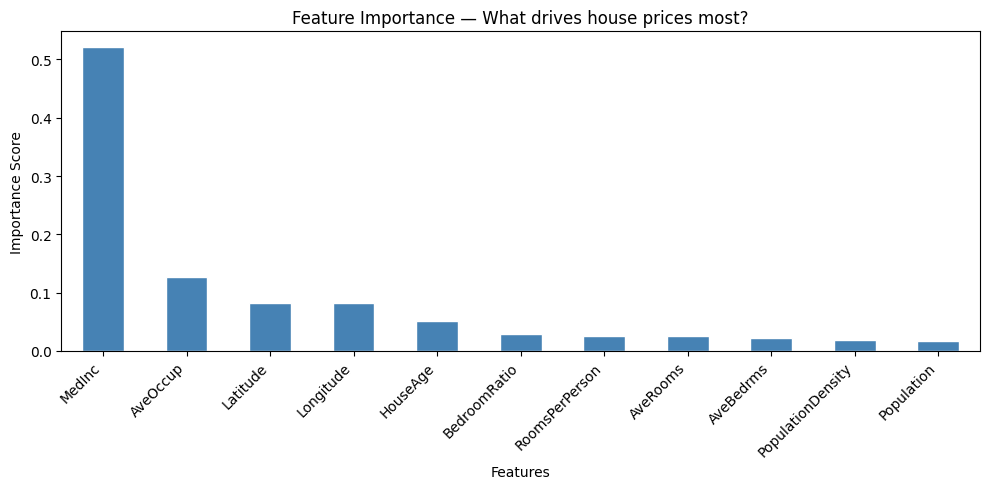


Top 3 most important features:
  1. MedInc: 0.5222
  2. AveOccup: 0.1263
  3. Latitude: 0.0824


In [20]:
# CELL 18 — Feature importance
importances = pd.Series(
    best_model.feature_importances_,  
    # array showing each feature's contribution to predictions
    # higher = model used this feature more for decisions
    index=X2.columns                  
    # label each score with its column name
).sort_values(ascending=False)        
# sort from most to least important

plt.figure(figsize=(10, 5))
importances.plot(
    kind='bar',        # vertical bar chart
    color='steelblue', # bar color
    edgecolor='white'  # white edges between bars
)
plt.title('Feature Importance — What drives house prices most?')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')  
# rotate x labels 45 degrees so they don't overlap each other
plt.tight_layout()                   
# prevents labels getting cut off at edges
plt.show()

print("\nTop 3 most important features:")
for i, (feature, score) in enumerate(importances.head(3).items()):
    print(f"  {i+1}. {feature}: {score:.4f}")

In [21]:
# CELL 19 — Save trained model and scaler to disk
import pickle

# save the best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("best_model.pkl saved!")
print("scaler.pkl saved!")

best_model.pkl saved!
scaler.pkl saved!
